<a href="https://colab.research.google.com/github/PSG72-cmd/Stroke-Prediction/blob/main/01_data_cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Stroke Prediction Dataset: Data Cleaning
**Team:** Prathmesh + teammate  |  **Tools:** Python, pandas, numpy, matplotlib, seaborn

Goal: clean the stroke dataset (missing values, duplicates, data types, outliers) and save a cleaned CSV.

## Step 1: Import libraries and load the data
We import the tools we need, then read the CSV into a table called `df`.
If the GitHub link fails, the code asks you to upload the CSV file by hand.

In [2]:
import pandas as pd              # pandas: for working with tables (dataframes)
import numpy as np               # numpy: for numbers and maths
import matplotlib.pyplot as plt  # matplotlib: for drawing charts
import seaborn as sns            # seaborn: makes charts look nicer

sns.set_style("whitegrid")       # clean white grid background for charts

url = "https://raw.githubusercontent.com/PSG72-cmd/Stroke-Prediction/main/healthcare-dataset-stroke-data.csv"  # link to our raw dataset on GitHub

try:
    df = pd.read_csv(url)        # read the csv file from GitHub into a table
except Exception:
    from google.colab import files
    print("GitHub link failed. Please upload healthcare-dataset-stroke-data.csv")
    uploaded = files.upload()                    # opens an upload button
    df = pd.read_csv(list(uploaded.keys())[0])   # read the file you uploaded

original_rows = df.shape[0]      # remember how many rows we started with
df.head()                        # show the first 5 rows

GitHub link failed. Please upload healthcare-dataset-stroke-data.csv


Saving healthcare-dataset-stroke-data.csv to healthcare-dataset-stroke-data.csv


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


## Step 2: Explore the data
We check the size of the table, the type of each column, and basic statistics.

In [3]:
print("Rows and columns:", df.shape)   # (number of rows, number of columns)
df.info()                                # column names, data types, non-empty counts

Rows and columns: (5110, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [4]:
df.describe()   # min, max, mean, etc. for the number columns

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


## Step 3: Check missing values
Empty cells can break analysis. `isnull().sum()` counts empty cells in each column.

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64


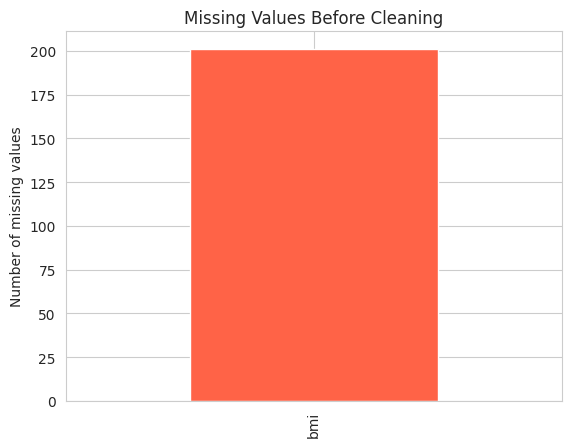

In [5]:
print(df.isnull().sum())                     # count of empty cells per column

missing = df.isnull().sum()                  # same count, saved in a variable
missing = missing[missing > 0]               # keep only columns that have missing values
missing.plot(kind="bar", color="tomato")     # draw a bar chart
plt.title("Missing Values Before Cleaning")  # chart title
plt.ylabel("Number of missing values")       # y-axis label
plt.show()                                   # display the chart

## Step 4: Fill missing BMI values
We fill empty `bmi` cells with the **median**. Median is better than mean here because extreme values pull the mean up or down, but the median stays in the middle.

In [6]:
median_bmi = df["bmi"].median()           # find the middle value of bmi
print("Median BMI:", median_bmi)
df["bmi"] = df["bmi"].fillna(median_bmi)  # replace empty cells with the median
print(df.isnull().sum())                  # check: everything should now be 0

Median BMI: 28.1
id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64


## Step 5: Check and remove duplicates
Duplicate rows would count the same person twice.

In [7]:
print("Duplicate rows:", df.duplicated().sum())   # rows that are exact copies
print("Duplicate ids:", df["id"].duplicated().sum())  # repeated patient ids
df = df.drop_duplicates()                            # remove duplicate rows (if any)
print("Rows after removing duplicates:", df.shape[0])

Duplicate rows: 0
Duplicate ids: 0
Rows after removing duplicates: 5110


## Step 6: Fix odd values
The gender column has one row with 'Other'. With only one row it is not useful, so we remove it.
In `smoking_status`, 'Unknown' means the status was not recorded. We keep it as its own group.

In [8]:
print(df["gender"].value_counts())             # how many of each gender
df = df[df["gender"] != "Other"]               # keep every row except gender = Other
print(df["smoking_status"].value_counts())     # how many of each smoking group

gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64
smoking_status
never smoked       1892
Unknown            1544
formerly smoked     884
smokes              789
Name: count, dtype: int64


## Step 7: Fix data types
`id` is just a label, so we drop it. Text columns with a few fixed groups are converted to the `category` type.

In [9]:
df = df.drop(columns=["id"])   # remove the id column

cat_cols = ["gender", "ever_married", "work_type", "Residence_type", "smoking_status"]  # text columns
for col in cat_cols:                       # go through each column one by one
    df[col] = df[col].astype("category")   # change its type to category

df.info()   # confirm the new data types

<class 'pandas.core.frame.DataFrame'>
Index: 5109 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   gender             5109 non-null   category
 1   age                5109 non-null   float64 
 2   hypertension       5109 non-null   int64   
 3   heart_disease      5109 non-null   int64   
 4   ever_married       5109 non-null   category
 5   work_type          5109 non-null   category
 6   Residence_type     5109 non-null   category
 7   avg_glucose_level  5109 non-null   float64 
 8   bmi                5109 non-null   float64 
 9   smoking_status     5109 non-null   category
 10  stroke             5109 non-null   int64   
dtypes: category(5), float64(3), int64(3)
memory usage: 305.1 KB


## Step 8: Look for outliers
Outliers are values far away from the rest. In a box plot, they show up as dots outside the box.
We save a copy of the data first so we can compare before and after.

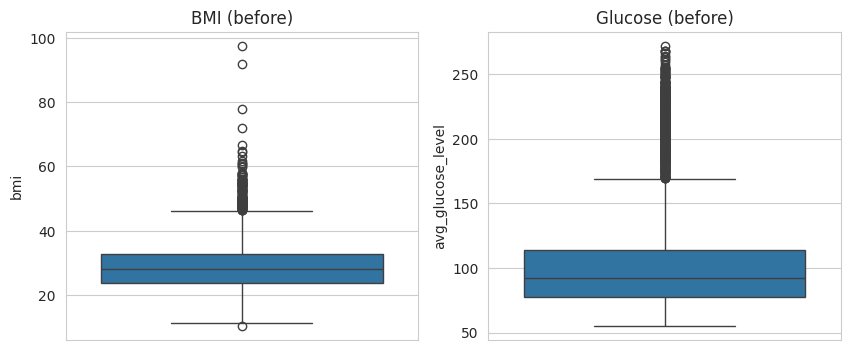

In [10]:
df_before = df.copy()   # backup of the data before fixing outliers

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)                  # left chart
sns.boxplot(y=df["bmi"])              # box plot of bmi
plt.title("BMI (before)")
plt.subplot(1, 2, 2)                  # right chart
sns.boxplot(y=df["avg_glucose_level"])  # box plot of glucose
plt.title("Glucose (before)")
plt.show()

## Step 9: Treat outliers with the IQR method
- Q1 = 25% point, Q3 = 75% point, IQR = Q3 - Q1
- Lower limit = Q1 - 1.5 x IQR, upper limit = Q3 + 1.5 x IQR
- Values beyond the limits are outliers. We **cap** them at the limit instead of deleting rows.

`def` makes a reusable recipe, so we write the steps once and use them for two columns.

In [11]:
def cap_outliers(col):
    Q1 = df[col].quantile(0.25)    # 25% point of the data
    Q3 = df[col].quantile(0.75)    # 75% point of the data
    IQR = Q3 - Q1                  # the spread of the middle half
    lower = Q1 - 1.5 * IQR         # below this = outlier
    upper = Q3 + 1.5 * IQR         # above this = outlier
    count = ((df[col] < lower) | (df[col] > upper)).sum()   # how many outliers
    print(col, "-> outliers found:", count, "| limits:", round(lower, 2), "to", round(upper, 2))
    df[col] = df[col].clip(lower, upper)   # pull extreme values back to the limit

cap_outliers("bmi")                 # run the recipe on bmi
cap_outliers("avg_glucose_level")   # run the recipe on glucose

bmi -> outliers found: 126 | limits: 10.3 to 46.3
avg_glucose_level -> outliers found: 627 | limits: 21.96 to 169.36


## Step 10: Compare before vs after

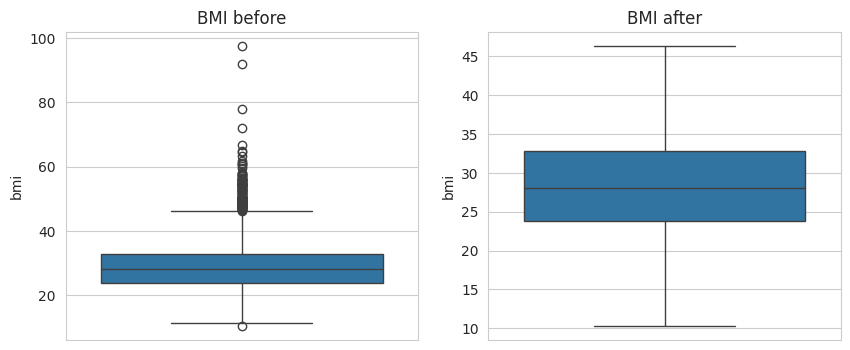

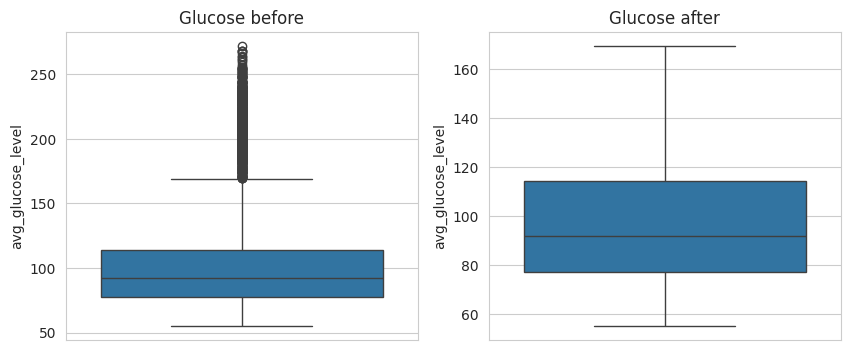

In [12]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.boxplot(y=df_before["bmi"])     # old data
plt.title("BMI before")
plt.subplot(1, 2, 2)
sns.boxplot(y=df["bmi"])            # cleaned data
plt.title("BMI after")
plt.show()

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.boxplot(y=df_before["avg_glucose_level"])
plt.title("Glucose before")
plt.subplot(1, 2, 2)
sns.boxplot(y=df["avg_glucose_level"])
plt.title("Glucose after")
plt.show()

## Step 11: Save the cleaned data
The cleaned file downloads to your laptop. Upload it to GitHub next.

In [13]:
df.to_csv("stroke_cleaned.csv", index=False)   # save the cleaned table as a csv file

try:
    from google.colab import files
    files.download("stroke_cleaned.csv")        # download it to your laptop
except Exception:
    print("Saved as stroke_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Step 12: Final summary (use these numbers in the report)

In [14]:
print("Original rows:", original_rows)
print("Final shape:", df.shape)
print("Missing values left:", df.isnull().sum().sum())
print("Data types:")
print(df.dtypes)

Original rows: 5110
Final shape: (5109, 11)
Missing values left: 0
Data types:
gender               category
age                   float64
hypertension            int64
heart_disease           int64
ever_married         category
work_type            category
Residence_type       category
avg_glucose_level     float64
bmi                   float64
smoking_status       category
stroke                  int64
dtype: object


## Summary of cleaning
- Missing `bmi` values filled with the median
- Duplicates checked (and removed if found)
- One 'Other' gender row removed
- `id` column dropped
- 5 text columns converted to category type
- Outliers in `bmi` and `avg_glucose_level` capped with the IQR method
- Cleaned data saved as `stroke_cleaned.csv`